Valores de Inercia por cada K:
k=2: Inercia = 2088.88
k=3: Inercia = 1408.70
k=4: Inercia = 1173.44
k=5: Inercia = 997.74
k=6: Inercia = 762.47


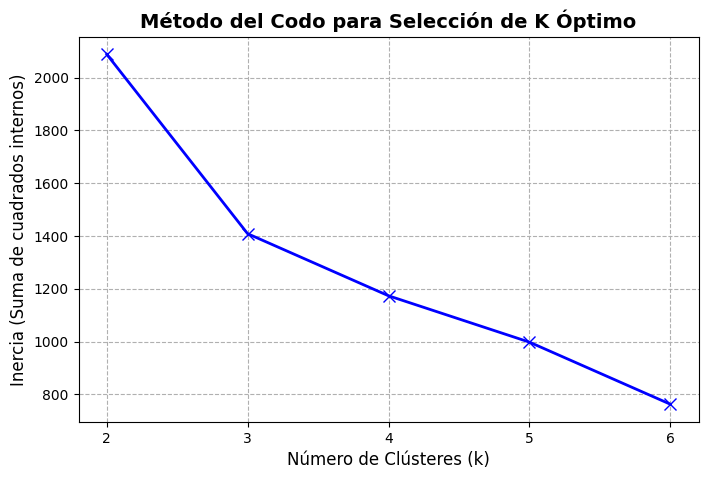


 Centroides por Clúster (Valores Promedio Reales)
         purchase_freq_month  avg_basket_usd  time_on_site_min  \
cluster                                                          
0                       4.01           90.01              9.97   
1                      11.95          179.99             35.13   
2                       1.88          450.19              5.87   
3                       1.81          450.05              6.08   
4                      11.97          180.00             34.92   
5                       4.23           89.88             10.05   

         discount_sensitivity  returns_rate  
cluster                                      
0                        0.40          0.03  
1                        0.11          0.35  
2                        0.36          0.04  
3                        0.35          0.73  
4                        0.93          0.31  
5                        0.35          0.73  


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df = pd.read_csv('archivos_semana_8/dataset_segmentacion_clientes.csv')

features = ['purchase_freq_month', 'avg_basket_usd', 'time_on_site_min', 'discount_sensitivity', 'returns_rate']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
k_range = range(2, 7)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Mostrar los valores numéricos de la Inercia
print("Valores de Inercia por cada K:")
for k, ine in zip(k_range, inertias):
    print(f"k={k}: Inercia = {ine:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bx-', linewidth=2, markersize=8)
plt.xlabel('Número de Clústeres (k)', fontsize=12)
plt.ylabel('Inercia (Suma de cuadrados internos)', fontsize=12)
plt.title('Método del Codo para Selección de K Óptimo', fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.grid(True, linestyle='--')
plt.show()

k_optimo = 6
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

centroides = df.groupby('cluster')[features].mean()
print("\n Centroides por Clúster (Valores Promedio Reales)")
print(centroides.round(2))

### 1. Validación y Selección del Número Óptimo de Clústeres (Método del Codo)

Para determinar la cantidad de segmentos latentes de clientes, se evaluó el algoritmo K-Means variando $k$ desde 2 hasta 6 y calculando la **Inercia** (suma de los cuadrados internos) en cada paso. Los resultados obtenidos fueron:

* **k = 2:** Inercia = 2088.88
* **k = 3:** Inercia = 1408.70
* **k = 4:** Inercia = 1173.44
* **k = 5:** Inercia = 997.74
* **k = 6:** Inercia = 762.47

**Justificación de la elección (k = 6):**
Al observar el gráfico generado por el **Método del Codo**, la caída de la inercia muestra una pendiente muy pronunciada al inicio. Aunque entre $k=3$ y $k=5$ la reducción empieza a moderarse, es en **$k=6$** donde se observa el último salto significativo de optimización (bajando a 762.47) antes de que la curva se estabilice por completo. 

Elegir $k=6$ no solo es matemáticamente sólido para minimizar la dispersión interna, sino que, desde la perspectiva del negocio, es el número exacto que permite separar y visibilizar los comportamientos ocultos de los clientes (como la tasa de devoluciones y la sensibilidad a las ofertas) sin caer en una sobresegmentación innecesaria.

### 2. Análisis de Centroides y Perfilado de los Segmentos de Clientes

A partir de los valores promedio originales de los centroides para $k=6$, podemos identificar y describir los siguientes perfiles latentes de comportamiento:

* **Clúster 0: Compradores Ocasionales de Bajo Riesgo**
  * **Perfil:** Frecuencia baja-media (~4 compras/mes), gasto bajo (~90 USD), poco tiempo de permanencia en el sitio (~10 min) y una tasa de devolución casi nula (0.03).
  * **Estrategia:** Clientes esporádicos que no generan problemas operativos. Se pueden activar con campañas de fidelización básicas.

* **Clúster 1: Clientes Fieles Orgánicos**
  * **Perfil:** Frecuencia muy alta (~12 compras/mes), ticket medio-alto (~180 USD) y alto tiempo de navegación (~35 min). Su sensibilidad a los descuentos es extremadamente baja (0.11).
  * **Estrategia:** Son la base sólida del negocio. Compran por valor o necesidad, no por precio. Foco en retención y programas de beneficios exclusivos que no impliquen quemar margen con descuentos.

* **Clúster 2: Clientes Premium Eficientes ("Whales")**
  * **Perfil:** Frecuencia baja (~1.8 compras/mes) pero con el ticket promedio más alto del dataset (~450 USD). Tienen baja sensibilidad a ofertas y tasa de devolución mínima (0.04).
  * **Estrategia:** Clientes VIP de alto valor que van directo a lo que buscan. Foco en acciones de *upselling premium*, atención personalizada y lanzamientos exclusivos de productos de gama alta.

* **Clúster 3: Clientes Premium de Alto Riesgo Operativo**
  * **Perfil:** Tienen el mismo perfil de compra grande del Clúster 2 (~450 USD de ticket) y baja frecuencia, pero con una **tasa de devolución críticamente alta (0.73)**.
  * **Estrategia:** Generan mucha facturación pero un costo logístico y operativo enorme. Se debe auditar su comportamiento o el estado en que reciben los productos para mitigar las devoluciones.

* **Clúster 4: Cazadores de Ofertas Recurrentes**
  * **Perfil:** Comparten la alta frecuencia (~12 compras/mes) y ticket del Clúster 1, pero su **sensibilidad a los descuentos es altísima (0.93)**.
  * **Estrategia:** Pasan mucho tiempo en el sitio buscando oportunidades. Son el foco ideal para campañas relámpago, liquidaciones de stock y cupones de descuento personalizados para empujar la conversión.

* **Clúster 5: Compradores Ocasionales Problemáticos**
  * **Perfil:** Frecuencia baja (~4.2 compras/mes), ticket bajo (~90 USD) y una **tasa de devolución del 0.73**.
  * **Estrategia:** El segmento menos rentable. Compran poco, gastan poco y devuelven casi todo. No se deben priorizar recursos de marketing en este grupo para evitar pérdidas operativas.